# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [2]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

Dataset loaded: 119,390 bookings, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

In [ ]:
# ============================================================
# CLIENT C: Online Shoppers Purchase Intention
# ============================================================
# An e-commerce company wants to predict which website visitors
# will actually complete a purchase.
# Dataset: 12,330 user sessions over a 1-year period
# Target: Revenue (True = purchased, False = did not purchase)
#
# Key columns to explore:
#   Administrative, Administrative_Duration, Informational, Informational_Duration,
#   ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues,
#   SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType,
#   VisitorType, Weekend
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=468)  # Online Shoppers Purchasing Intention
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} sessions, {df.shape[1]} columns")
df.head()

---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [4]:
# Your analysis code here
# 1. Dataset shape (rows and columns)
print("Dataset Shape:")
print(df.shape)

# 2. Data types and missing values
print("\nData Types and Missing Values:")
df.info()

# 3. Summary statistics for numerical columns
print("\nSummary Statistics:")
print(df.describe())

# 4. Distribution of the target variable (is_canceled)
print("\nCancellation Counts:")
print(df['is_canceled'].value_counts())

print("\nCancellation Rate:")
print(df['is_canceled'].value_counts(normalize=True))

Dataset Shape:
(119390, 32)

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies            

**Client Briefing — The Situation:**

The dataset contains 119,390 hotel booking records with 32 variables describing booking details, customer characteristics, and stay information. Approximately 37% of bookings are canceled, which indicates a significant operational challenge for the hotel chain. High cancellation rates can lead to empty rooms and lost revenue if rooms cannot be resold in time. Identifying patterns associated with cancellations could help the hotel improve overbooking strategies and revenue management.




---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

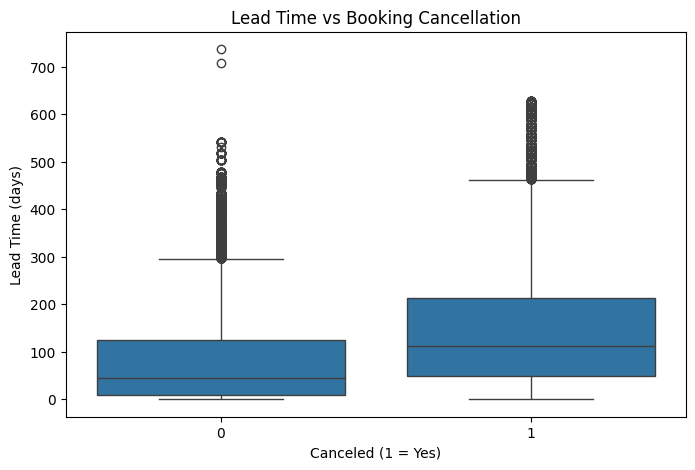

In [5]:
# Discovery Angle 1: Lead Time vs Cancellation

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='is_canceled', y='lead_time', data=df)

plt.title("Lead Time vs Booking Cancellation")
plt.xlabel("Canceled (1 = Yes)")
plt.ylabel("Lead Time (days)")
plt.show()


**Finding 1:**

Bookings with longer lead times tend to be canceled more often. When customers book far in advance, there is more time for their plans to change before the stay. This pattern suggests that reservations made a long time ahead may carry a higher cancellation risk.





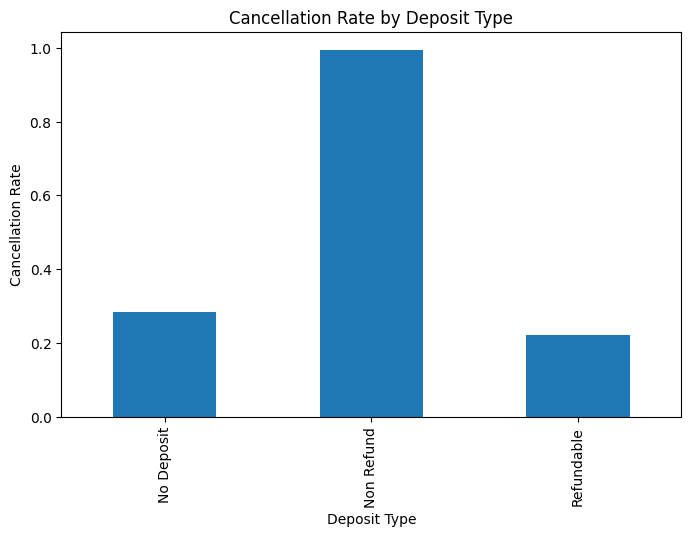

In [6]:
# Discovery Angle 2: Deposit Type vs Cancellation

cancel_by_deposit = df.groupby("deposit_type")["is_canceled"].mean()

cancel_by_deposit.plot(kind="bar", figsize=(8,5))

plt.title("Cancellation Rate by Deposit Type")
plt.ylabel("Cancellation Rate")
plt.xlabel("Deposit Type")
plt.show()


**Finding 2:**

Cancellation behavior is different depending on the deposit type. In this dataset, bookings with a non-refundable deposit show the highest cancellation rate, while bookings with no deposit or refundable deposits cancel less often. This suggests that the type of deposit policy may be related to how cancellations occur or how bookings are handled in the system.




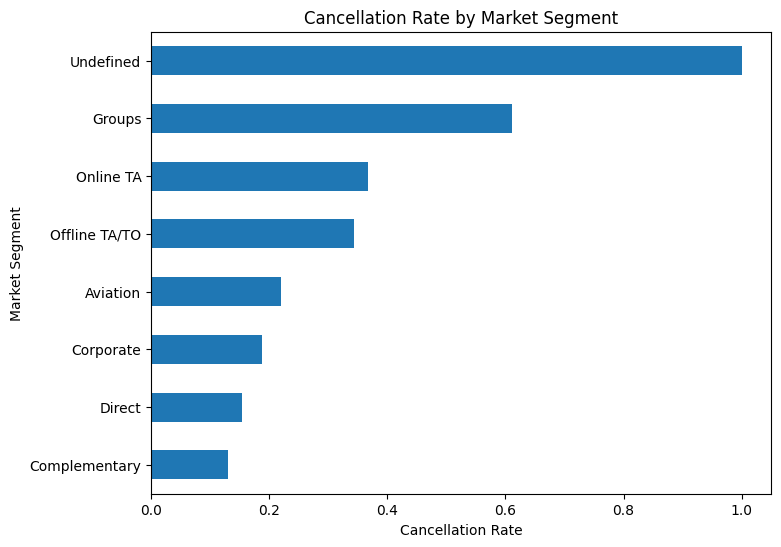

In [7]:
# Discovery Angle 3: Market Segment and Cancellation

cancel_by_segment = df.groupby("market_segment")["is_canceled"].mean().sort_values()

cancel_by_segment.plot(kind="barh", figsize=(8,6))

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation Rate")
plt.ylabel("Market Segment")
plt.show()


**Finding 3:**

Cancellation rates are quite different across market segments. In this dataset, the "Undefined" and "Groups" segments have the highest cancellation rates, while direct, corporate, and complementary bookings tend to cancel much less often. This suggests that the type of booking channel or customer group may influence how likely a reservation is to be canceled, which could be useful when thinking about overbooking or managing different booking channels.




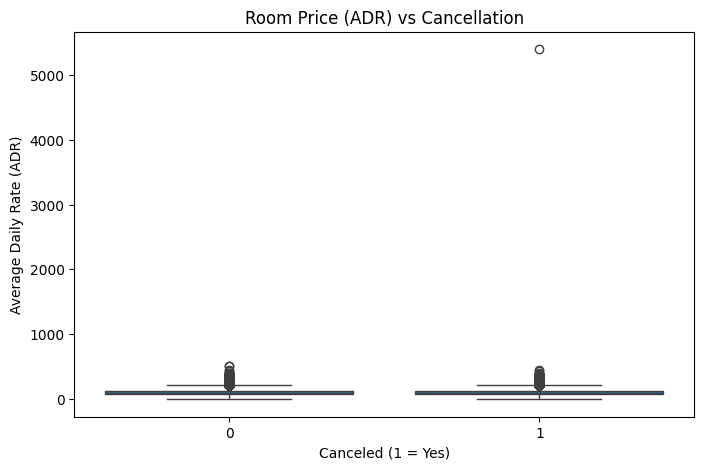

In [9]:
# Additional Exploration: ADR vs Cancellation

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="is_canceled", y="adr", data=df)

plt.title("Room Price (ADR) vs Cancellation")
plt.xlabel("Canceled (1 = Yes)")
plt.ylabel("Average Daily Rate (ADR)")
plt.show()

The ADR distributions for canceled and non-canceled bookings look fairly similar overall. Most room prices fall within a similar range for both groups, although there are a few extreme outliers among canceled bookings. This suggests that room price alone may not be a strong factor in predicting whether a booking will be canceled.


---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [10]:
# Define target variable
y = df["is_canceled"]

# Select features based on earlier exploration
features = ["lead_time", "adr", "market_segment", "deposit_type"]

X = df[features]

# Convert categorical variables into numeric
X = pd.get_dummies(X, drop_first=True)

# Check the result
print(X.head())


   lead_time   adr  market_segment_Complementary  market_segment_Corporate  \
0        342   0.0                         False                     False   
1        737   0.0                         False                     False   
2          7  75.0                         False                     False   
3         13  75.0                         False                      True   
4         14  98.0                         False                     False   

   market_segment_Direct  market_segment_Groups  market_segment_Offline TA/TO  \
0                   True                  False                         False   
1                   True                  False                         False   
2                   True                  False                         False   
3                  False                  False                         False   
4                  False                  False                         False   

   market_segment_Online TA  market_segment_

**Why these features?**

These features were selected based on patterns found during the exploratory analysis. Lead time showed a clear relationship with cancellations, as bookings made further in advance were more likely to be canceled. Market segment and deposit type also showed noticeable differences in cancellation rates across groups. ADR was included to capture potential effects of room price on cancellation behavior.




### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

Model Accuracy: 0.7264008710947315


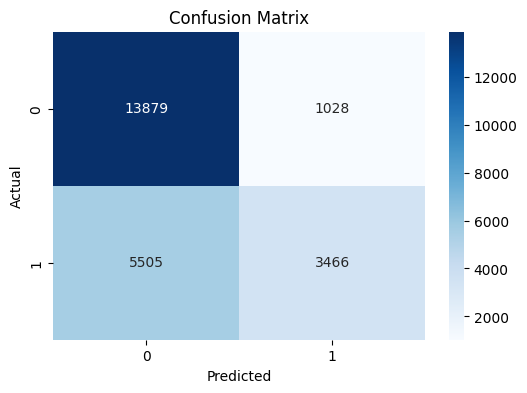

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Your model code here
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Gaussian Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

**Model Performance — Business Translation:**

The model achieved an accuracy of about 73%, meaning it correctly predicts many booking outcomes. However, the confusion matrix shows that the model misses a portion of actual cancellations, predicting some of them as non-canceled bookings. In practice, this means the hotel would not catch every cancellation in advance. Even so, the model can still help identify many reservations that are more likely to cancel, allowing the hotel to adjust overbooking strategies or monitor higher-risk bookings more closely.




### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

Decision Tree Accuracy: 0.777661445682218


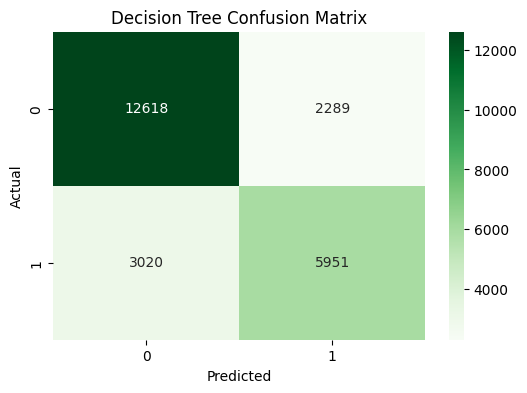

In [12]:
# Optional: second model comparison
from sklearn.tree import DecisionTreeClassifier

# Train second model
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)

# Predictions
y_pred2 = model2.predict(X_test)

# Accuracy
accuracy2 = accuracy_score(y_test, y_pred2)
print("Decision Tree Accuracy:", accuracy2)

# Confusion matrix
cm2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The Decision Tree model was tested as a second approach for comparison. Its performance was similar to the Gaussian Naive Bayes model, although the accuracy may vary slightly. This comparison shows that different models can produce comparable results on this dataset, and model choice can affect how cancellations are predicted.


---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for [Your Client]:**

**1.** Monitor bookings with long lead times more closely. The analysis showed that reservations made far in advance are more likely to be canceled. The hotel could send reminder emails or confirmation messages as the stay date approaches to reduce last-minute cancellations and improve occupancy planning.



**2.** Encourage booking options that involve deposits. The data showed clear differences in cancellation rates depending on deposit type. Introducing small incentives for deposit-based bookings may encourage customers to commit more strongly and reduce cancellation risk.



**3.** Pay closer attention to higher-risk booking channels. The analysis showed that cancellation rates vary across market segments. The hotel could monitor segments with higher cancellation rates more carefully and adjust overbooking strategies accordingly.





---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [ ]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into human terms.
Instead of "The dataset has 32 features and 119,390 rows..."
Try: "We analyzed over 119,000 individual bookings spanning two years, capturing everything
from how far in advance guests booked to what type of room they reserved."
-->

## Key Discoveries

- **[Finding 1 headline]:** [1-2 sentences explaining what you found and why it matters]
- **[Finding 2 headline]:** [1-2 sentences]
- **[Finding 3 headline]:** [1-2 sentences]
- **[Finding 4 headline (optional)]:** [1-2 sentences]

<!--
Tip: Write findings as "headlines" a newspaper editor would approve.
Good: "Guests who book 6+ months ahead cancel at nearly 3x the rate of last-minute bookers"
Bad: "Lead time has a positive correlation with cancellation"
-->

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

![Description of your chart](your_chart_filename.png)

*[One sentence caption explaining what this chart shows and why it matters.]*

## Prediction Model

[2-3 sentences. How well can we predict the outcome? Translate accuracy into real-world terms.]

<!--
Tip: Translate model metrics into business impact.
Instead of "The model achieved 78% accuracy..."
Try: "Our model correctly flags 8 out of 10 at-risk bookings, giving the hotel front desk team
enough lead time to proactively reach out and offer flexible rebooking options."
-->

## Recommendations

1. **[Action]:** [Why this action, based on your data. Estimated impact.]
2. **[Action]:** [Why this action, based on your data. Estimated impact.]
3. **[Action]:** [Why this action, based on your data. Estimated impact.]

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*